In [2]:
import sys
from pathlib import Path

# Make the project's src/ folder importable, whether the notebook runs from
# the project root or from inside notebooks/.
ROOT = next(p for p in [Path.cwd(), Path.cwd().parent] if (p / "src").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
from src.data import load_features, load_activity_map

# The baseline uses the 561 pre-computed features.
X_train, y_train, subj_train = load_features("train")
X_test,  y_test,  subj_test  = load_features("test")

id_to_activity = load_activity_map()
class_names = [id_to_activity[i] for i in range(1, 7)]

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train:", y_train.shape, "| y_test:", y_test.shape)
print("Classes:", class_names)

X_train: (7352, 561) | X_test: (2947, 561)
y_train: (7352,) | y_test: (2947,)
Classes: ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']


In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Random Forest = an ensemble of many decision trees, each trained on a random
# subset of data/features; they vote. Strong on tabular data, needs no scaling,
# and is a classic, honest baseline.
rf = RandomForestClassifier(
    n_estimators=300,   # number of trees (more = steadier, a bit slower)
    random_state=42,    # fixed seed so results are reproducible
    n_jobs=-1,          # use all CPU cores
)
rf.fit(X_train, y_train)

# Evaluate on the UNSEEN test subjects (the honest number).
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Random Forest test accuracy (unseen subjects): {acc:.4f}  ({acc*100:.2f}%)")

Random Forest test accuracy (unseen subjects): 0.9287  (92.87%)


In [4]:
from sklearn.metrics import classification_report, f1_score, recall_score

print(classification_report(y_test, y_pred, target_names=class_names, digits=3))

print(f"Macro-F1:     {f1_score(y_test, y_pred, average='macro'):.3f}")
print(f"Macro-recall: {recall_score(y_test, y_pred, average='macro'):.3f}")

                    precision    recall  f1-score   support

           WALKING      0.900     0.976     0.936       496
  WALKING_UPSTAIRS      0.904     0.915     0.909       471
WALKING_DOWNSTAIRS      0.968     0.857     0.909       420
           SITTING      0.912     0.886     0.899       491
          STANDING      0.897     0.921     0.909       532
            LAYING      1.000     1.000     1.000       537

          accuracy                          0.929      2947
         macro avg      0.930     0.926     0.927      2947
      weighted avg      0.930     0.929     0.929      2947

Macro-F1:     0.927
Macro-recall: 0.926


Saved figure to: C:\Users\abel\Documents\Python_projects\The HAR project\reports\figures\rf_confusion_matrix.png


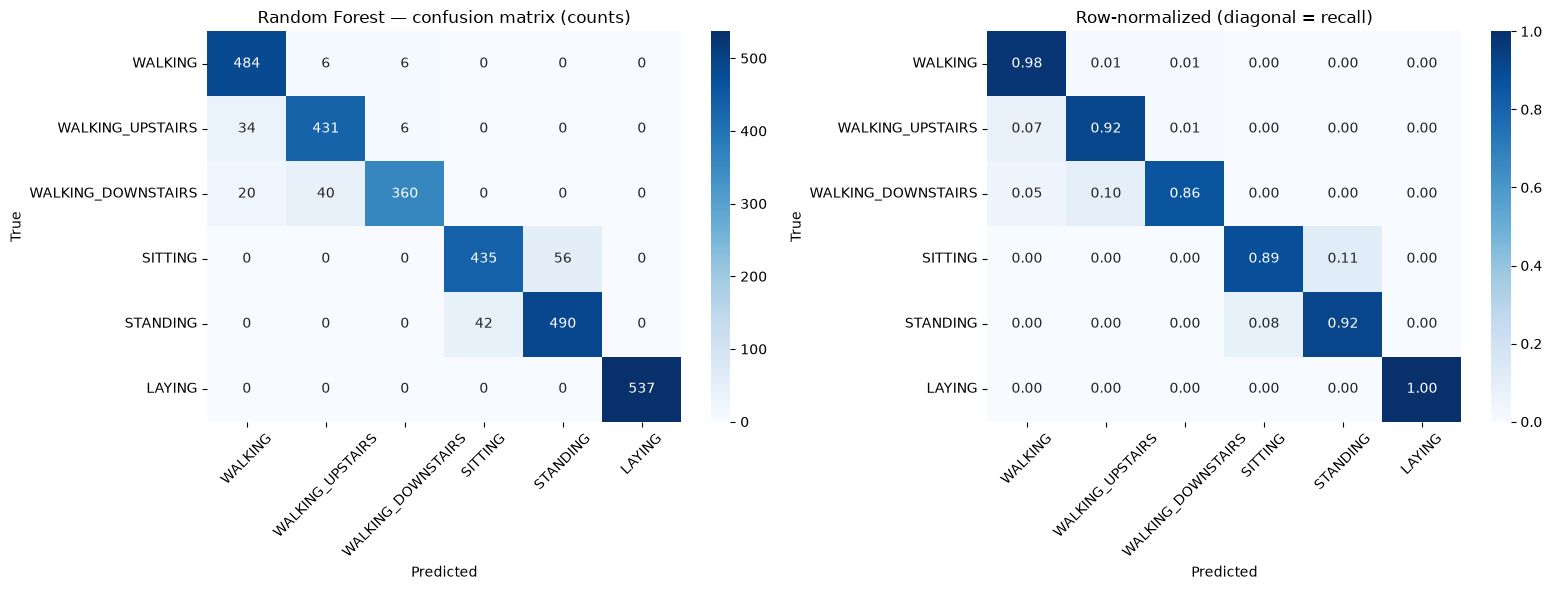

In [5]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm      = confusion_matrix(y_test, y_pred)                    # raw counts
cm_norm = confusion_matrix(y_test, y_pred, normalize="true")  # row-normalized = recall per class

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title("Random Forest — confusion matrix (counts)")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title("Row-normalized (diagonal = recall)")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")

for ax in axes:
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
fig_dir = next(p for p in [Path("reports/figures"), Path("../reports/figures")] if p.exists())
out_path = fig_dir / "rf_confusion_matrix.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print("Saved figure to:", out_path.resolve())
plt.show()